## Milestone 1.1

In [ ]:
!nvidia-smi

Mon Apr 17 01:12:44 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   43C    P8     9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

Your runtime has 13.6 gigabytes of available RAM



In [ ]:
import requests
import pickle
import zipfile
import time
import os
#from google.colab import drive
import random
import glob
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import asarray
from PIL.ImageStat import Stat
!pip install pydicom
import pydicom
# Package for converting PNG Files to DICOM(.dcm ) format
!pip install simpleitk
import SimpleITK as sitk
from sklearn.model_selection import train_test_split
from PIL import Image
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import DataFrameIterator
#from keras_preprocessing.image.dataframe_iterator import DataFrameIterator
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense, Activation, MaxPool2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.1 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 MB 10.8 MB/s eta 0:00:00


In [ ]:
data_path = './content'
archive_path = data_path + '/data/'
if os.path.exists(archive_path):
  print(f"{archive_path} directory exists.")
else:
  print(f"Did not find {archive_path} directory, creating one...")
  os.mkdir('./content')

  os.mkdir(archive_path)
  if os.path.exists(archive_path):
    print(f'{archive_path} created successfully')



Did not find ./content/data/ directory, creating one...
./content/data/ created successfully


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!mv /content/gdrive/MyDrive/Manning_Projects/archive\ \(2\).zip /content/gdrive/MyDrive/Manning_Projects/covid_data.zip
!ls /content/gdrive/MyDrive/Manning_Projects/

mv: cannot stat '/content/gdrive/MyDrive/Manning_Projects/archive (2).zip': No such file or directory
'Copy of Project_XRAY_Resnet50_fc_removed.ipynb'
 covid_data.zip
 model_best_weights.zip
 Project_XRAY_Resnet18.ipynb
 Project_XRAY_Resnet50.ipynb
 Project_XRAY_VGG16_transfer_learning_conv.ipynb
 Project_XRAY_VGG16_Transfer_Learning.ipynb
 Project_XRAY_ViT.ipynb
 XRAY_NFC_resnet50_model_best_weights.zip
 XRAY_resnet50_model_best_weights.zip


In [ ]:
DRIVE_PATH = '/content/gdrive/MyDrive/Manning_Projects/'
ARCHIVE_ZIP_FILE = DRIVE_PATH + 'covid_data.zip'
ARCHIVE_ZIP_FILE

'/content/gdrive/MyDrive/Manning_Projects/covid_data.zip'

In [ ]:
!cp {ARCHIVE_ZIP_FILE} ./content/data/

In [ ]:
archive_file =  archive_path + 'covid_data.zip'

size = os.path.getsize(archive_file)

print(f'Size of the file is {size/1024} MegaBytes.')

Size of the file is 796903.357421875 MegaBytes.


In [ ]:
with zipfile.ZipFile(archive_file, "r") as zip_ref:
  print("Unzipping archive")
  zip_ref.extractall(archive_path)

Unzipping archive


In [ ]:
!rm -rf ./content/data/COVID-19_Radiography_Dataset/Lung_Opacity

In [ ]:
!rm -rf ./content/data/COVID-19_Radiography_Dataset/Viral\ Pneumonia

In [ ]:
COVID_IMAGE_PATH = './content/data/COVID-19_Radiography_Dataset/COVID/images'
NON_COVID_IMAGE_PATH = './content/data/COVID-19_Radiography_Dataset/Normal/images'

In [ ]:
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [ ]:
walk_through_dir(COVID_IMAGE_PATH)

There are 0 directories and 3616 images in './content/data/COVID-19_Radiography_Dataset/COVID/images'.


In [ ]:
walk_through_dir(NON_COVID_IMAGE_PATH)

There are 0 directories and 10192 images in './content/data/COVID-19_Radiography_Dataset/Normal/images'.


In [ ]:

random.seed(42)

COVID_IMAGE_PATH_LIST = glob.glob(COVID_IMAGE_PATH + "/*.png")
len(COVID_IMAGE_PATH_LIST), type(COVID_IMAGE_PATH_LIST)

(3616, list)

In [ ]:
NON_COVID_IMAGE_PATH_LIST = glob.glob(NON_COVID_IMAGE_PATH + "/*.png")
len(NON_COVID_IMAGE_PATH_LIST), type(NON_COVID_IMAGE_PATH_LIST)

(10192, list)

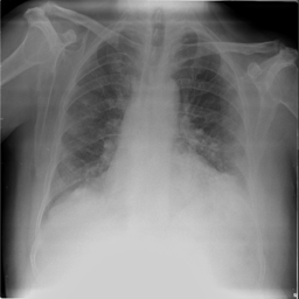

In [ ]:
random_image_cov = random.choice(COVID_IMAGE_PATH_LIST)
cov_pic = Image.open(random_image_cov).convert('L')
cov_pic.show()


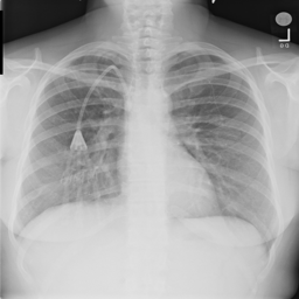

PIL.Image.Image

In [ ]:
random_image_ncov = random.choice(NON_COVID_IMAGE_PATH_LIST)
ncov_pic = Image.open(random_image_ncov).convert('L')
ncov_pic.show()
type(ncov_pic)

In [ ]:
def image_show(image_list, label):
  fig, subs = plt.subplots(3,3, figsize=(16,12))
  for i, sub in enumerate(subs.flatten()):
    #image_path = os.path.normpath(image[i])
    print(f'Image path is {image_list[i]} and label is {label}')
    img = Image.open(image_list[i])
    img.thumbnail((224,224))
    sub.imshow(img, cmap='gray')
    #sub.axis("off")
    print(f'Size of displayed image is {img.size}')
    sub.set_title(label)

In [ ]:
random.seed(3)
ll_d_c =  []
for i in range(9):
  im = random.choice(COVID_IMAGE_PATH_LIST)
  ll_d_c.append(im)
print(ll_d_c, len(ll_d_c))

ll_d_nc = []
for i in range(9):
  im = random.choice(NON_COVID_IMAGE_PATH_LIST)
  ll_d_nc.append(im)

print(ll_d_nc, len(ll_d_nc))


['./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-939.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1866.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-3602.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1481.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-2145.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-3351.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-205.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-411.png', './content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1156.png'] 9
['./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-7459.png', './content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-4799.png', './content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-5313.png', './content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-5039.png', './content/data/

Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-939.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1866.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-3602.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-1481.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-2145.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-3351.png and label is COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/COVID/images/COVID-205.png and label is COVID
Size of displayed image is (224, 224)
I

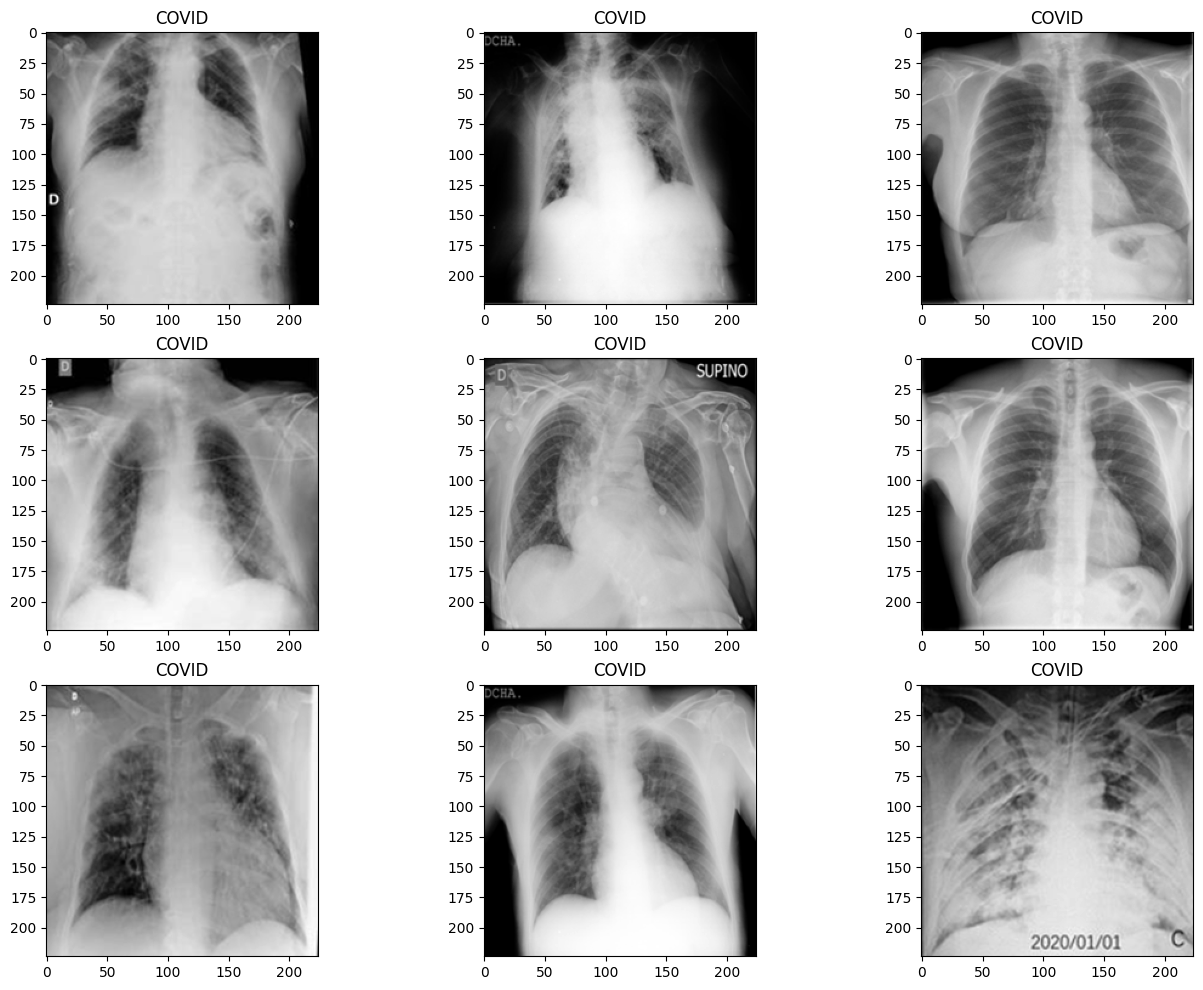

In [ ]:
image_show(ll_d_c, 'COVID')

Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-7459.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-4799.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-5313.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-5039.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-8739.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-7503.png and label is NON-COVID
Size of displayed image is (224, 224)
Image path is ./content/data/COVID-19_Radiography_Dataset/Normal/images/Normal-6736.png and label is NON-C

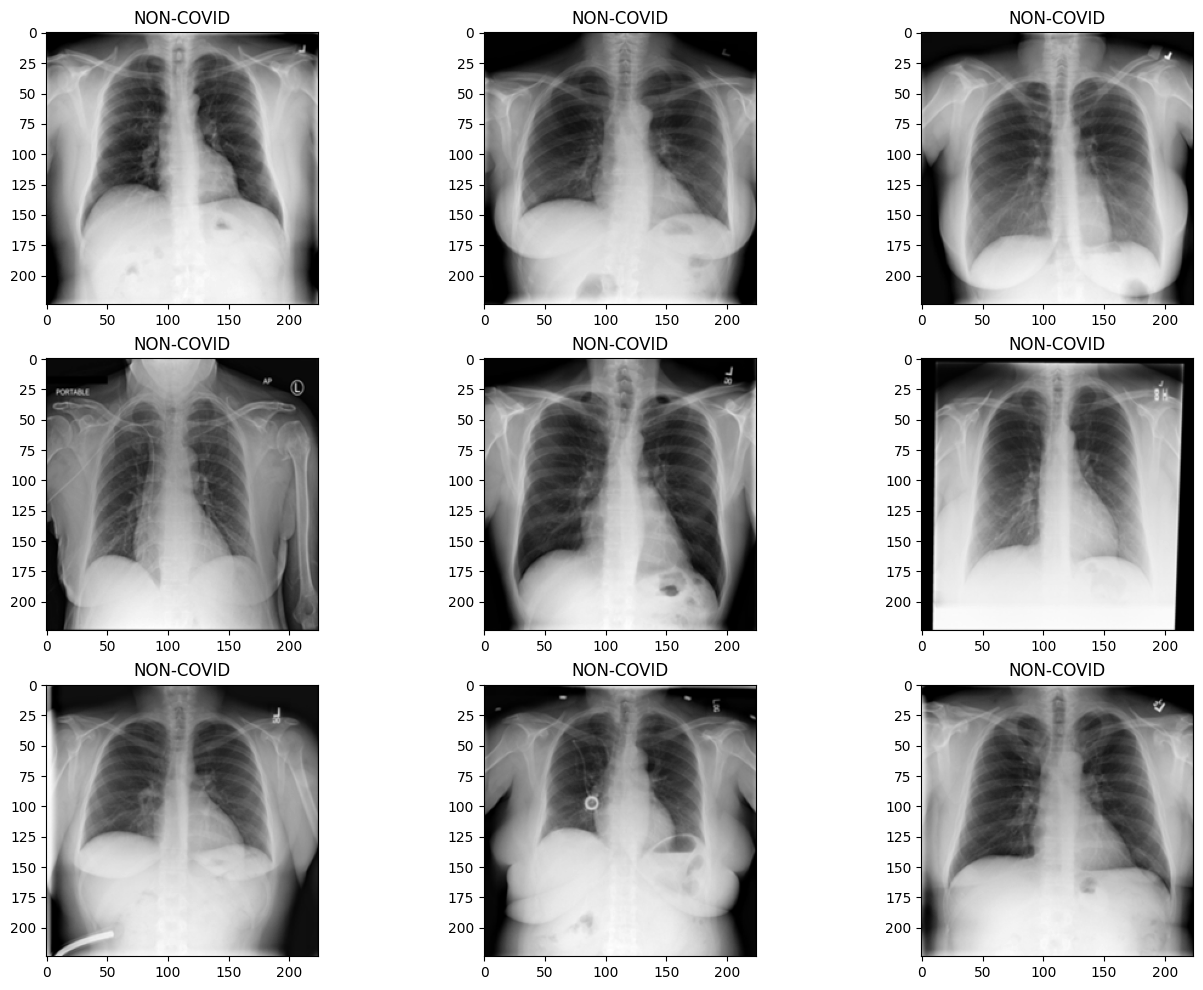

In [ ]:
image_show(ll_d_nc, 'NON-COVID')

In [ ]:
random_image = random.choice(COVID_IMAGE_PATH_LIST)
random_image_gs = Image.open(random_image).convert('L')
shape= random_image_gs.size
img= np.reshape(random_image_gs, (-1, *shape, 1))
img.shape

(1, 299, 299, 1)

In [ ]:
#def img_resize_save(img_path_list):
#  for i in range(len(img_path_list)):
#    temp_img = Image.open(img_path_list[i])
#    temp_img.thumbnail((224,224))
#    temp_img.save(img_path_list[i])
#  print('All images in supplied list resized to (224,224)')

#Originally I was under impression that all files have to be resized to 224,224 and then saved to disk. This is mentioned as a separate task.
#Hence, the logical deduction

In [ ]:
df = pd.DataFrame({'Class': [len(NON_COVID_IMAGE_PATH_LIST), len(COVID_IMAGE_PATH_LIST)]})

In [ ]:
total_class = df.Class.sum()
total_class

13808

In [ ]:
df['per_distr'] = df['Class'].apply(lambda x: x/total_class)
df.index = ['Non_Covid', 'Covid']

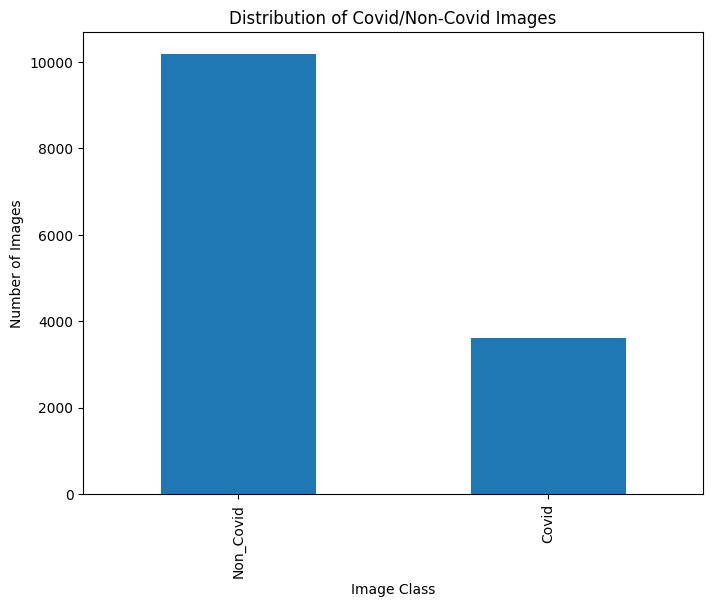

In [ ]:
df.Class.plot(kind="bar", figsize=(8,6))
plt.ylabel("Number of Images")
plt.xlabel("Image Class")
plt.title("Distribution of Covid/Non-Covid Images")
plt.show()

In [ ]:
list_arr = []
for pic in COVID_IMAGE_PATH_LIST:
  pic_np = np.array(Image.open(pic).convert('L'))
  pic_np = pic_np.reshape(299,299,1)
  list_arr.append(pic_np)


In [ ]:
len(list_arr)

3616

In [ ]:
covid_arr = np.array(list_arr)

In [ ]:
covid_arr.shape

(3616, 299, 299, 1)

In [ ]:
np.mean(covid_arr), np.min(covid_arr), np.max(covid_arr), np.std(covid_arr)


(139.52120961679765, 0, 255, 61.90712697550073)

In [ ]:
# Flatten the image data into a 1D array
pixel_values = covid_arr.flatten()

pixel_values.shape

(323274016,)

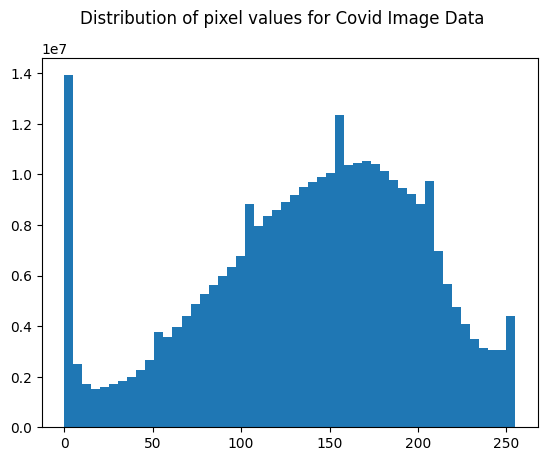

In [ ]:
# Plot a histogram of the pixel values
plt.hist(pixel_values, bins=50)
plt.suptitle("Distribution of pixel values for Covid Image Data")
plt.show()

In [ ]:
list_arr_nc = []
for pic in NON_COVID_IMAGE_PATH_LIST:
  pic_np_nc = np.array(Image.open(pic).convert('L'))
  pic_np_nc = pic_np_nc.reshape(299,299,1)
  list_arr_nc.append(pic_np_nc)
len(list_arr_nc)

10192

In [ ]:
covid_arr_nc = np.array(list_arr_nc)
covid_arr_nc.shape


(10192, 299, 299, 1)

In [ ]:
np.mean(covid_arr_nc), np.max(covid_arr_nc), np.mean(covid_arr_nc), np.std(covid_arr_nc)

(129.38979982014257, 255, 129.38979982014257, 66.21686464627402)

In [ ]:
# Flatten the image data into a 1D array
pixel_values_nc = covid_arr_nc.flatten()
pixel_values_nc.shape

(911174992,)

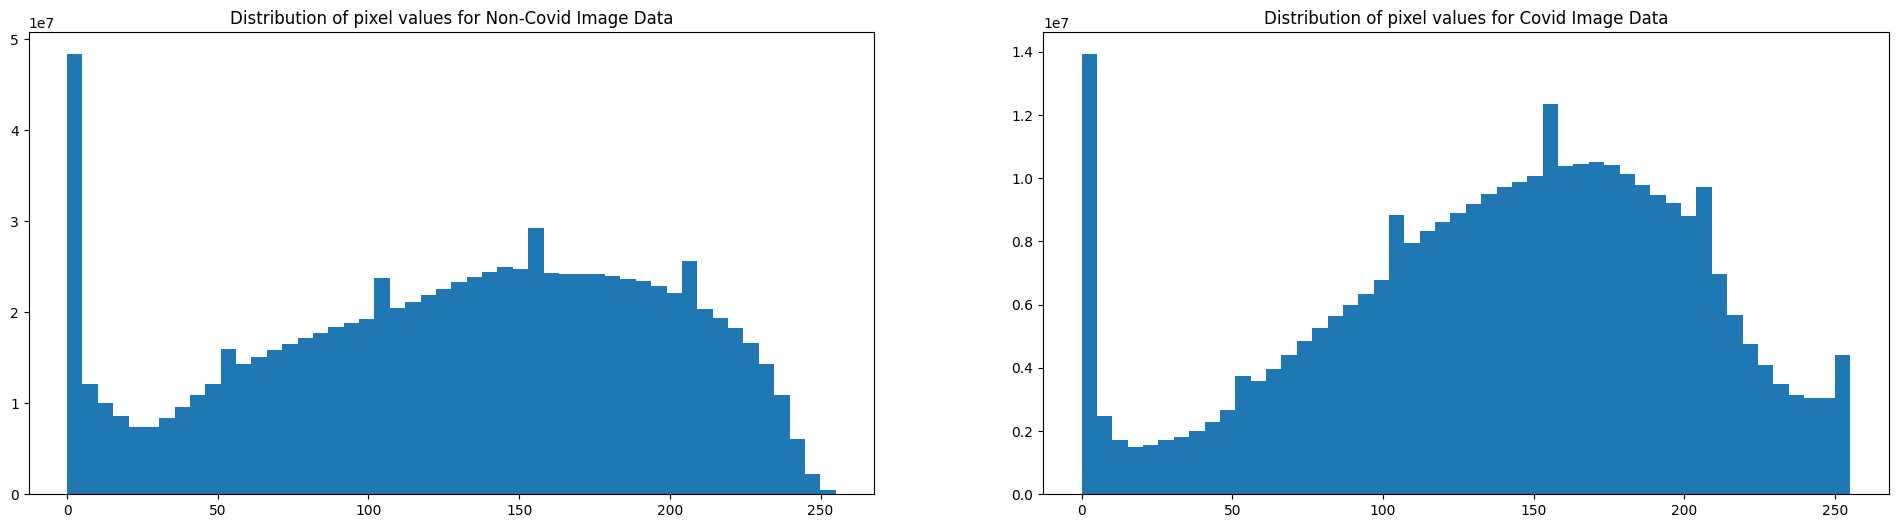

In [ ]:
# Plot a histogram of the pixel values
fig, subs = plt.subplots(1,2, figsize=(24,6))
for i, sub in enumerate(subs.flatten()):
  if i==0:
    sub.hist(pixel_values_nc, bins=50)
    sub.set_title("Distribution of pixel values for Non-Covid Image Data")
  else:
    sub.hist(pixel_values, bins=50)
    sub.set_title("Distribution of pixel values for Covid Image Data")




## Observation

It can be seen from above two histograms that pixel intensity for covid data is more peaked(kurtosis is high) than for non-covid images.

This confirms with fact that X-Ray images for covid infected patients show white patches in chest X-Ray Images.

In [ ]:
#Lets do simple check on whether the pixel data that we get from converted .dcm files is same what we get from original png image
image = COVID_IMAGE_PATH_LIST[0]
im1 = Image.open(image).convert('L')
im1= np.array(im1)
img= sitk.GetImageFromArray(im1)
sitk.WriteImage(img,'template.dcm')


<class 'numpy.ndarray'>


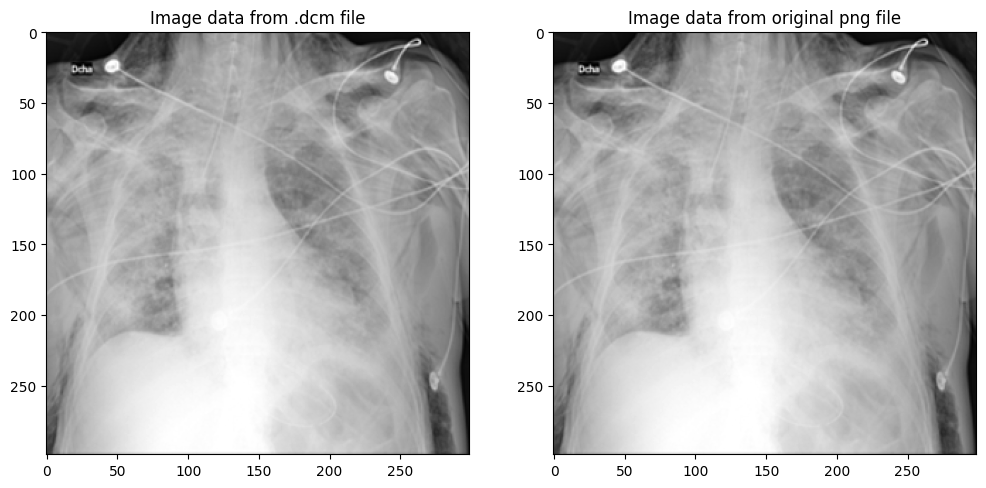

In [ ]:
fig, subs = plt.subplots(1,2, figsize=(12,6))
for i, sub in enumerate(subs.flatten()):
  if i==0:
    #ds = pydicom.dcmread('template.dcm')
    # Load the DICOM file
    ds = pydicom.dcmread('template.dcm')
    # Access the image data
    image_d = ds.pixel_array
    print(type(image_d))
    sub.imshow(image_d, cmap='gray')
    sub.set_title("Image data from .dcm file")
  else:
    sub.imshow(im1, cmap='gray')
    sub.set_title("Image data from original png file")

## It does looks like the data from both sources are one and same.
## STATUS : VERIFIED

## Convert all the PNG Files to DICOM (.dcm) Format

In [ ]:
DCM_FILE_PATH = './content/data/DCM/'
COVID_DCM_FILE_PATH = './content/data/DCM/COVID/'
NON_COVID_DCM_FILE_PATH = './content/data/DCM/NON_COVID/'
if os.path.exists(DCM_FILE_PATH):
  print(f"{DCM_FILE_PATH} directory exists.")
  if os.path.exists(COVID_DCM_FILE_PATH):
    print(f'{COVID_DCM_FILE_PATH} directory exists')
  else:
    print(f'Ok... looks like {COVID_DCM_FILE_PATH} does not exists. Let us make one')
    os.mkdir(COVID_DCM_FILE_PATH)
    print(f'{COVID_DCM_FILE_PATH} directory created successfully')
  if os.path.exists(NON_COVID_DCM_FILE_PATH):
    print(f'{NON_COVID_DCM_FILE_PATH} directory exists')
  else:
    print(f'Ok... looks like {NON_COVID_DCM_FILE_PATH} does not exists. Let us make one')
    os.mkdir(NON_COVID_DCM_FILE_PATH)
    print(f'{NON_COVID_DCM_FILE_PATH} directory created successfully')
else:
  print(f'Looks like there is no directory structure below /content/data.. Lets create required directory structures')
  print(f'Creating {DCM_FILE_PATH} directory path first')
  os.mkdir(DCM_FILE_PATH)
  print(f'{DCM_FILE_PATH} directory created successfully')

  print(f'Creating {COVID_DCM_FILE_PATH} directory path')
  os.mkdir(COVID_DCM_FILE_PATH)
  print(f'{COVID_DCM_FILE_PATH} directory created successfully')

  print(f'Creating {NON_COVID_DCM_FILE_PATH} directory path')
  os.mkdir(NON_COVID_DCM_FILE_PATH)
  print(f'{NON_COVID_DCM_FILE_PATH} directory created successfully')



Looks like there is no directory structure below /content/data.. Lets create required directory structures
Creating ./content/data/DCM/ directory path first
./content/data/DCM/ directory created successfully
Creating ./content/data/DCM/COVID/ directory path
./content/data/DCM/COVID/ directory created successfully
Creating ./content/data/DCM/NON_COVID/ directory path
./content/data/DCM/NON_COVID/ directory created successfully


In [ ]:

def pngtodcm(image_list, COVID, l_i):
  print(f'COVID variable is set to {COVID}')
  list_im = []
  list_im = l_i

  for png_image in image_list:
    png_im_arr = np.array(Image.open(png_image).convert('L'))
    dcm_im_arr = sitk.GetImageFromArray(png_im_arr)
    if COVID:
      SAVE_PATH = COVID_DCM_FILE_PATH
      list_im = list_im_c
    else:
      SAVE_PATH = NON_COVID_DCM_FILE_PATH
      list_im = list_im_nc
    FILENAME = png_image.split("/")[-1].split(".")[0]
    DCM_FILENAME = SAVE_PATH + FILENAME + '.dcm'
    sitk.WriteImage(dcm_im_arr, DCM_FILENAME)
    print(f'Successfully converted and saved {DCM_FILENAME}')
    list_im.append(DCM_FILENAME)




In [ ]:
list_im_c = []
pngtodcm(COVID_IMAGE_PATH_LIST, True, list_im_c)

COVID variable is set to True
Successfully converted and saved ./content/data/DCM/COVID/COVID-1727.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2823.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2563.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-1896.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-892.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-3337.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2647.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2037.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-2457.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-1451.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-1871.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-1654.dcm
Successfully converted and saved ./content/data/DCM/COVID/COVID-1319.dcm
Successfully converted

In [ ]:
len(list_im_c)

3616

In [ ]:
list_im_nc = []
pngtodcm(NON_COVID_IMAGE_PATH_LIST, False, list_im_nc)

Streaming output truncated to the last 5000 lines.
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-4432.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-1122.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-1352.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-14.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-2254.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-6038.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-9372.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-1073.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-7619.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-5518.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-5501.dcm
Successfully converted and saved ./content/data/DCM/NON_COVID/Normal-7202.dcm
Successfully co

In [ ]:
len(list_im_nc), len(list_im_c)

(10192, 3616)

In [ ]:
len(NON_COVID_IMAGE_PATH_LIST), len(COVID_IMAGE_PATH_LIST)

(10192, 3616)

In [ ]:
list_im_nc[0], list_im_c[0]

('./content/data/DCM/NON_COVID/Normal-1089.dcm',
 './content/data/DCM/COVID/COVID-1727.dcm')

In [ ]:
def extract_fnames(file_list):
  temp_ll = []
  for i in file_list:
    fname = i.split("/")[-1].split(".")[0]
    temp_ll.append(fname)
    return sorted(temp_ll)

In [ ]:
ll_dc_fname = extract_fnames(list_im_c)
ll_dnc_fname = extract_fnames(list_im_nc)
ll_pc_fname = extract_fnames(COVID_IMAGE_PATH_LIST)
ll_pnc_fname = extract_fnames(NON_COVID_IMAGE_PATH_LIST)



In [ ]:
ll_dc_fname == ll_pc_fname

True

In [ ]:
ll_dnc_fname == ll_pnc_fname

True

In [ ]:
df_nc = pd.DataFrame()

In [ ]:
df_nc['filename'] = list_im_nc

In [ ]:
df_nc['class'] = 0

In [ ]:
df_nc

,filename,class
0,./content/data/DCM/NON_COVID/Normal-1089.dcm,0
1,./content/data/DCM/NON_COVID/Normal-5957.dcm,0
2,./content/data/DCM/NON_COVID/Normal-1316.dcm,0
3,./content/data/DCM/NON_COVID/Normal-5054.dcm,0
4,./content/data/DCM/NON_COVID/Normal-4166.dcm,0
...,...,...
10187,./content/data/DCM/NON_COVID/Normal-3729.dcm,0
10188,./content/data/DCM/NON_COVID/Normal-2865.dcm,0
10189,./content/data/DCM/NON_COVID/Normal-4231.dcm,0
10190,./content/data/DCM/NON_COVID/Normal-1020.dcm,0


In [ ]:
label_1 = list(np.ones(len(list_im_c), dtype=int))
len(label_1), len(list_im_c)

(3616, 3616)

In [ ]:
dict_c = {'filename': list_im_c, 'class': label_1}

In [ ]:
df_c = pd.DataFrame(data=dict_c)

In [ ]:
df_c

,filename,class
0,./content/data/DCM/COVID/COVID-1727.dcm,1
1,./content/data/DCM/COVID/COVID-2823.dcm,1
2,./content/data/DCM/COVID/COVID-2563.dcm,1
3,./content/data/DCM/COVID/COVID-1896.dcm,1
4,./content/data/DCM/COVID/COVID-892.dcm,1
...,...,...
3611,./content/data/DCM/COVID/COVID-817.dcm,1
3612,./content/data/DCM/COVID/COVID-1508.dcm,1
3613,./content/data/DCM/COVID/COVID-3292.dcm,1
3614,./content/data/DCM/COVID/COVID-2159.dcm,1


In [ ]:
df = pd.concat([df_nc, df_c])

In [ ]:
df.reset_index(inplace=True)

In [ ]:
df.drop(columns=['index'], inplace=True)

In [ ]:
df

,filename,class
0,./content/data/DCM/NON_COVID/Normal-1089.dcm,0
1,./content/data/DCM/NON_COVID/Normal-5957.dcm,0
2,./content/data/DCM/NON_COVID/Normal-1316.dcm,0
3,./content/data/DCM/NON_COVID/Normal-5054.dcm,0
4,./content/data/DCM/NON_COVID/Normal-4166.dcm,0
...,...,...
13803,./content/data/DCM/COVID/COVID-817.dcm,1
13804,./content/data/DCM/COVID/COVID-1508.dcm,1
13805,./content/data/DCM/COVID/COVID-3292.dcm,1
13806,./content/data/DCM/COVID/COVID-2159.dcm,1


In [ ]:
df['class'].value_counts()

0    10192
1     3616
Name: class, dtype: int64

In [ ]:
df.to_csv('./content/data/DCM/dcm_files_list_labels.csv', index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13808 entries, 0 to 13807
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  13808 non-null  object
 1   class     13808 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 215.9+ KB


## Milestone 1.2

In [ ]:
df_loaddata = pd.read_csv('./content/data/DCM/dcm_files_list_labels.csv')

In [ ]:
df_loaddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13808 entries, 0 to 13807
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  13808 non-null  object
 1   class     13808 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 215.9+ KB


In [ ]:
len(df_loaddata.filename.unique())

13808

In [ ]:
df_loaddata['class'].value_counts()

0    10192
1     3616
Name: class, dtype: int64

In [ ]:
df_X = df_loaddata.drop(columns=['class'])
df_y = df_loaddata['class']

In [ ]:
df_y.head(), df_X.head()

(0    0
 1    0
 2    0
 3    0
 4    0
 Name: class, dtype: int64,
                                        filename
 0  ./content/data/DCM/NON_COVID/Normal-1089.dcm
 1  ./content/data/DCM/NON_COVID/Normal-5957.dcm
 2  ./content/data/DCM/NON_COVID/Normal-1316.dcm
 3  ./content/data/DCM/NON_COVID/Normal-5054.dcm
 4  ./content/data/DCM/NON_COVID/Normal-4166.dcm)

In [ ]:
train_df, test_df = train_test_split(df_loaddata, test_size=0.2, random_state=42, stratify=df['class'])

len(train_df), len(test_df)

(11046, 2762)

In [ ]:
# we need to further reserve 20% data in training for validation
train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['class'])

len(train_df), len(valid_df)

(8836, 2210)

In [ ]:
train_df['class'].sum(), valid_df['class'].sum(), test_df['class'].sum()

(2314, 579, 723)

In [ ]:
train_df['class'].sum() + valid_df['class'].sum() + test_df['class'].sum()

3616

In [ ]:
train_aug_params = dict(
    #rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range = [0.8, 1.2]
)

valid_aug_params = dict(
    #rescale=1./255
    )

test_aug_params = dict(
    #rescale=1./255
)


In [ ]:
#Creating augmenters

train_augmenter = ImageDataGenerator(**train_aug_params)
valid_augmenter = ImageDataGenerator(**valid_aug_params)
test_augmenter = ImageDataGenerator(**test_aug_params)

In [ ]:
type(train_augmenter), type(valid_augmenter), type(test_augmenter)

(keras.preprocessing.image.ImageDataGenerator,
 keras.preprocessing.image.ImageDataGenerator,
 keras.preprocessing.image.ImageDataGenerator)

In [ ]:
# training parameters
BATCH_SIZE = 32
COLOR_MODE = 'grayscale'
TARGET_SIZE = (224, 224)
EPOCHS = 10

train_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE,
}

valid_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE,
    'shuffle': False
}

test_consts = {
    'batch_size': BATCH_SIZE,
    'color_mode': COLOR_MODE,
    'target_size': TARGET_SIZE,  # resize input images
    'shuffle': False
}


In [ ]:
class DCMDataFrameIterator(DataFrameIterator):
    def __init__(self, *arg, **kwargs):
        self.white_list_formats = ('dcm')
        super(DCMDataFrameIterator, self).__init__(*arg, **kwargs)
        self.dataframe = kwargs['dataframe']
        self.x = self.dataframe[kwargs['x_col']]
        self.y = self.dataframe[kwargs['y_col']]
        self.color_mode = kwargs['color_mode']
        self.target_size = kwargs['target_size']

    def _get_batches_of_transformed_samples(self, indices_array):
        # get batch of images
        batch_x = np.array([self.read_dcm_as_array(dcm_path, self.target_size, color_mode=self.color_mode)
                            for dcm_path in self.x.iloc[indices_array]])

        batch_y = np.array(self.y.iloc[indices_array].astype(np.uint8))  # astype because y was passed as str

        # transform images
        if self.image_data_generator is not None:
            for i, (x, y) in enumerate(zip(batch_x, batch_y)):
                transform_params = self.image_data_generator.get_random_transform(x.shape)
                batch_x[i] = self.image_data_generator.apply_transform(x, transform_params)

                # you can change y here as well, eg: in semantic segmentation you want to transform masks as well
                # using the same image_data_generator transformations.

        return batch_x, batch_y

    @staticmethod
    def read_dcm_as_array(dcm_path, target_size=(256, 256), color_mode='rgb'):
        image_array = pydicom.dcmread(dcm_path).pixel_array
        image = Image.fromarray(image_array) #converts from array to PIL
        #image = Image.open(image).convert('L')
        image.thumbnail((224,224)) #resize image to 224,224
        #image_array = cv2.resize(image_array, target_size, interpolation=cv2.INTER_NEAREST)  #this returns a 2d array
        image_array = np.expand_dims(image, -1)
        return image_array.astype(np.float32)

In [ ]:
train_df['class'] = train_df['class'].astype('str')
valid_df['class'] = valid_df['class'].astype('str')
test_df['class'] = test_df['class'].astype('str')

In [ ]:
train_df.info(), valid_df.info(),  test_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8836 entries, 13528 to 8134
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  8836 non-null   object
 1   class     8836 non-null   object
dtypes: object(2)
memory usage: 207.1+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2210 entries, 6681 to 12452
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2210 non-null   object
 1   class     2210 non-null   object
dtypes: object(2)
memory usage: 51.8+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2762 entries, 1939 to 8436
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2762 non-null   object
 1   class     2762 non-null   object
dtypes: object(2)
memory usage: 64.7+ KB


(None, None, None)

In [ ]:
train_generator = DCMDataFrameIterator(dataframe=train_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=train_augmenter,
                             **train_consts)

valid_generator = DCMDataFrameIterator(dataframe=valid_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=valid_augmenter,
                             **valid_consts)

test_generator = DCMDataFrameIterator(dataframe=test_df,
                             x_col='filename',
                             y_col='class',
                             image_data_generator=test_augmenter,
                             **test_consts)

Found 8836 validated image filenames belonging to 2 classes.
Found 2210 validated image filenames belonging to 2 classes.
Found 2762 validated image filenames belonging to 2 classes.


In [ ]:
#train_augmenter.fit(train_generator)

In [ ]:
classes = ['NON-COVID', 'COVID']

In [ ]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(train_generator))

imgs.shape, labels.shape, type(imgs), type(labels)

((32, 224, 224, 1), (32,), numpy.ndarray, numpy.ndarray)

In [ ]:
imgs[0].mean(), imgs[0].max(), imgs[0].min()

(145.31837, 255.0, 0.0)

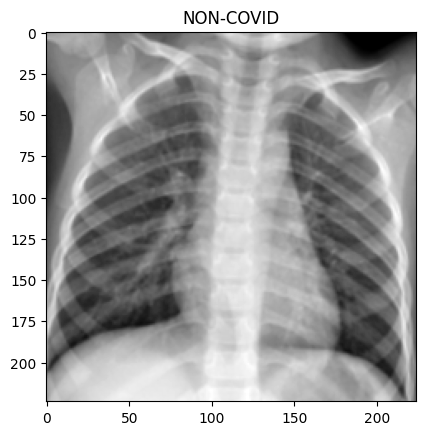

In [ ]:
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

(32, 224, 224, 1) (32,) <class 'numpy.ndarray'> <class 'numpy.ndarray'>


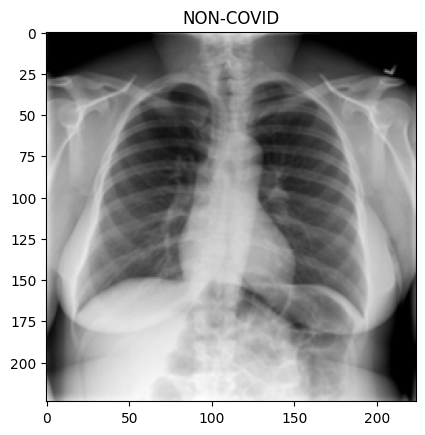

In [ ]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(valid_generator))
print(imgs.shape, labels.shape, type(imgs), type(labels))
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

(32, 224, 224, 1) (32,) <class 'numpy.ndarray'> <class 'numpy.ndarray'>


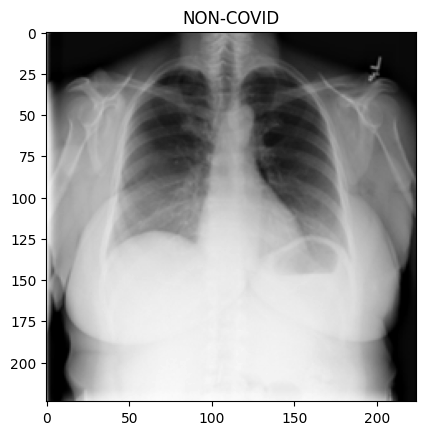

In [ ]:
#Lets fetch some images from generator to ensure it is working good
imgs, labels = next(iter(test_generator))
print(imgs.shape, labels.shape, type(imgs), type(labels))
plt.imshow(imgs[0], cmap='gray')
plt.title(classes[labels[0]])
plt.show()

In [ ]:
imgs[0].dtype

dtype('float32')

In [ ]:
#imgs[0]

In [ ]:
#help(train_generator)

In [ ]:
#help(tensorflow.python.keras.layers.convolutional.Conv2D)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Add, Flatten, LayerNormalization, Activation, Input
from tensorflow.keras import Sequential
try:
    from einops import rearrange, repeat
    from einops.layers.tensorflow import Rearrange
except:
    print("Einops not installed, Initiating install")
    !pip install einops
    from einops import rearrange, repeat
    from einops.layers.tensorflow import Rearrange
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

Einops not installed, Initiating install
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 3.7 MB/s eta 0:00:00


In [ ]:
basemodel = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(224,224,3)), pooling='avg')
basemodel.summary()

58889256/58889256 [==============================] - 2s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                              

In [ ]:
class VGG16_TL(tensorflow.keras.Model):
  def __init__(self):
    super().__init__()

    self.conv_layer = Conv2D(3, (3,3), padding='same')

    self.basemodel = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(224,224,3)))
    for layer in self.basemodel.layers:
      layer.trainable=False
    self.classifier = Sequential([
        Flatten(),
        Dense(4096, use_bias=False),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.25),
        Dense(4096, use_bias=False),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.25),
        Dense(2)
    ])

  def call(self,x):
    #for layer in self.basemodel.layers:
     # layer.trainable=False
    x = self.conv_layer(x)
    x = preprocess_input(x)
    x = self.basemodel(x)
    x = self.classifier(x)
    return x

In [ ]:
model = VGG16_TL()

In [ ]:
X_input = Input(shape=(224,224,1,))
out = VGG16_TL()(X_input)
temp_model = Model(inputs=X_input, outputs=out)
temp_model.summary(expand_nested=True)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 1)]     0         
                                                                 
 vgg16_tl_1 (VGG16_TL)       (None, 2)                 134293344 
|¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯|
| conv2d_1 (Conv2D)         multiple                  30        |
|                                                               |
| vgg16 (Functional)        (None, 7, 7, 512)         14714688  |
||¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯¯||
|| input_4 (InputLayer)    [(None, 224, 224, 3)]     0         ||
||                                                             ||
|| block1_conv1 (Conv2D)   (None, 224, 224, 64)      1792      ||
||                                                             ||
|| block1_conv2 (Conv2D)   (None, 224, 224, 64)      36928   

In [ ]:
from tensorflow.keras.optimizers.schedules import LearningRateSchedule
from tensorflow import data, train, math, reduce_sum, cast, equal, argmax, \
float32, GradientTape, TensorSpec, function, int64

In [ ]:
opt = Adam(learning_rate=0.0001)
loss_fn = tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
train_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()
test_acc_metric = tensorflow.keras.metrics.SparseCategoricalAccuracy()


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
if os.path.exists('./content/data/ckpt'):
    print(f'Weight Checkpoint directory already exists')
    !ls -ld ./content/data/ckpt
else:
    print(f'Weight Checkpooint directory doesnt exists.. Creating it now..')
    os.mkdir('./content/data/ckpt')
    print(f'Weight Checkpoint directory successfully created')
    !ls -ld ./content/data/ckpt


if os.path.exists('./content/data/saved_model'):
    print(f'Protobuf Checkpoint directory already exists')
    !ls -ld ./content/data/saved_model
else:
    print(f'Protobuf Checkpoint directory doesnt exists.. Creating it now..')
    os.mkdir('./content/data/saved_model')
    print(f'Weight Checkpoint directory successfully created')
    !ls -ld ./content/data/saved_model

Weight Checkpooint directory doesnt exists.. Creating it now..
Weight Checkpoint directory successfully created
drwxr-xr-x 2 root root 4096 Apr 17 01:16 ./content/data/ckpt
Protobuf Checkpoint directory doesnt exists.. Creating it now..
Weight Checkpoint directory successfully created
drwxr-xr-x 2 root root 4096 Apr 17 01:16 ./content/data/saved_model


In [ ]:
class Model_Train():
  def __init__(self, model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen, train_acc_metric, val_acc_metric, test_acc_metric):
    super().__init__()

    self.model = model
    self.optimizer = optimizer
    self.loss_fn = loss_fn
    self.epochs = epochs
    self.batch_size = batch_size
    self.train_generator = train_gen
    self.valid_generator = valid_gen
    self.test_generator = test_gen
    self.steps_train = len(train_gen)
    self.steps_valid = len(valid_gen)
    self.steps_test = len(test_gen)
    self.train_acc_metric = train_acc_metric
    self.val_acc_metric = val_acc_metric
    self.test_acc_metric = test_acc_metric
    self.train_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': []}
    self.valid_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'ckpt_name': []}




  @tensorflow.function
  def train_step(self, train_data, train_label):
    with tensorflow.GradientTape() as tape:
      output = self.model(train_data, training=True)
      loss_value = self.loss_fn(train_label, output)
    grads = tape.gradient(loss_value, self.model.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.model.trainable_weights))
    self.train_acc_metric.update_state(train_label, output)
    return output, loss_value

  @tensorflow.function
  def test_step(self, validation_data, validation_label):
    val_output = self.model(validation_data, training=False)
    loss_value = self.loss_fn(validation_label, val_output)
    self.val_acc_metric.update_state(validation_label, val_output)
    return val_output, loss_value

  def getloss_accuracy(self, gen, batch_size, steps_per_epoch, df, train=False, valid=False):
    loss_epoch = 0
    n=0
    for step, (x_batch, y_batch) in enumerate(gen):
      if train:
        output, loss_value = self.train_step(x_batch, y_batch)
        ###new code below

        pred_labls = list(np.argmax(output.numpy(), axis=1))
        temp_df = pd.DataFrame({'orig_label': list(y_batch), 'pred_label': pred_labls})
        df = pd.concat([df, temp_df])


        ## newcode above

      else:
        output, loss_value = self.test_step(x_batch, y_batch)
        pred_labls = list(np.argmax(output.numpy(), axis=1))
        temp_df = pd.DataFrame({'orig_label': list(y_batch), 'pred_label': pred_labls})
        df = pd.concat([df, temp_df])

      loss_epoch += loss_value*x_batch.shape[0]
      #n = n+1
      #print("Training step ", n )
      if step >= (steps_per_epoch-1):
        if train:
          avg_epoch_loss = (loss_epoch/(len(train_df))).numpy()
          accuracy = self.train_acc_metric.result().numpy()
          self.train_acc_metric.reset_states()
          gen.on_epoch_end()
        else:
          if valid:
            avg_epoch_loss = (loss_epoch/(len(valid_df))).numpy()
            accuracy = self.val_acc_metric.result().numpy()
            self.val_acc_metric.reset_states()
          else:
            avg_epoch_loss = (loss_epoch/(len(test_df))).numpy()
            accuracy = self.val_acc_metric.result().numpy()
            self.val_acc_metric.reset_states()


        return df, avg_epoch_loss, accuracy

  def train_validate_loop(self):
    for epoch in range(self.epochs):
      start_time = time.time()
      histdf_train = pd.DataFrame({'orig_label': [], 'pred_label': []})
      histdf_val   = pd.DataFrame({'orig_label': [], 'pred_label': []})

      df_train_cm, avg_epoch_train_loss, train_accuracy = self.getloss_accuracy(self.train_generator, self.batch_size, self.steps_train, histdf_train, train=True)
      df_val_cm, avg_epoch_val_loss, val_accuracy = self.getloss_accuracy(self.valid_generator, self.batch_size, self.steps_valid, histdf_val, train=False, valid=True)


      f1, precision, recall             = self.calc_rec_prec_f1(df_train_cm, train=True)
      f1_val, precision_val, recall_val = self.calc_rec_prec_f1(df_val_cm, train=False)


      print(f'Epoch : {epoch}, Train Loss: {avg_epoch_train_loss}, Train Accuracy: {train_accuracy}, Validation Loss: {avg_epoch_val_loss}, Validation Accuracy: {val_accuracy}')

      self.train_history['loss'].append(avg_epoch_train_loss)
      self.train_history['accuracy'].append(train_accuracy)
      self.train_history['f1'].append(f1)
      self.train_history['precision'].append(precision)
      self.train_history['recall'].append(recall)

      self.valid_history['loss'].append(avg_epoch_val_loss)
      self.valid_history['accuracy'].append(val_accuracy)
      self.valid_history['f1'].append(f1_val)
      self.valid_history['precision'].append(precision_val)
      self.valid_history['recall'].append(recall_val)

      ###New Code for early stopping#####
      la = self.valid_history['accuracy']
      if (len(la) > 4):
        if (((la[-1] <= la[-2]) and (la[-2] <= la[-3])) and ((la[-3] <= la[-4]) and (la[-4] <= la[-5]))):
          print("Validation accuracy has not improved over last 4 epochs, hence invoking early stopping and exiting training process")
          if len(self.valid_history['ckpt_name']) > 0:
            print('Loading Best weights..')
            self.model.load_weights(self.valid_history['ckpt_name'][-1])
            break
          else:
            print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")
            break

      if ((la[-1] > 0.9) and (len(la) > 1)):
        if(la[-1] > max(la[0:-1])):
          self.save_checkpoint(la[-1])
      elif ((la[-1] > 0.9) and (len(la) == 1)):
        self.save_checkpoint(la[-1])





      #####New Cod for early stopping



      print(f'Time taken: {np.round((time.time() - start_time), 4)}')
    print(f'Training completed successfully. Loading best checkpoint weights ...')
    if len(self.valid_history['ckpt_name']) > 0:
      self.model.load_weights(self.valid_history['ckpt_name'][-1])
      print(f'Best checkpoint weights loaded : {self.valid_history["ckpt_name"][-1]}')
    else:
      print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")

      #draw graph depicting train and validation losses and accuracy + recall, f1
    return self.train_history, self.valid_history

  def save_checkpoint(self, acc):
    ckpt_name = './content/data/ckpt/' + 'ckpt' + '_' + str(acc) + '_acc.pt'
    pb_name = './content/data/saved_model/' + 'ckpt' + '_' + str(acc) + '_acc'
    self.model.save_weights(ckpt_name)
    self.valid_history['ckpt_name'].append(ckpt_name)
    print(f'Saved Checkpoint : {ckpt_name}')
    self.model.save(pb_name)
    print(f'Saved model in protobuf format : {pb_name}')


  def get_test_accuracy(self):
    df = pd.DataFrame({'orig_label': [], 'pred_label': []})
    df_test, avg_test_loss, test_accuracy = self.getloss_accuracy(self.test_generator, self.batch_size, self.steps_test, df)
    return df_test, avg_test_loss, test_accuracy

  def calc_rec_prec_f1(self, df, train):
    print_string = "Training Confusion Matrix" if train else "Validation Confusion Matrix"
    print(print_string, "\n", confusion_matrix(df['orig_label'], df['pred_label']))
    tn, fp, fn, tp = confusion_matrix(df['orig_label'], df['pred_label']).ravel()
    precision = tp/(tp+fp)
    recall = tp/(tp+fn)
    f1 = 2*precision*recall/(precision+recall)
    return f1, precision, recall

  def predict_single(self,dcm_path, target_size=(224,224)):
    image_array = pydicom.dcmread(dcm_path).pixel_array
    image = Image.fromarray(image_array) #converts from array to PIL
    #image.thumbnail((224,224)) #resize image to 224,224
    image = image.resize((224,224))
    image_array = np.expand_dims(image, 0)
    image_array = image_array.astype(np.float32) # * (1.0/255.0)
    image_array = np.expand_dims(image_array, -1)
    output = self.model(image_array, training=False)
    pred_label = np.argmax(output.numpy())
    print(f'Predicted label for image supplied is : {classes[pred_label]}')
    return classes[pred_label]

  def pred_image_show(self,image_list):
    fig, subs = plt.subplots(3,3, figsize=(14,12))
    for i, sub in enumerate(subs.flatten()):
      print(f'Image path is {image_list[i][0]} and Original label is {classes[int(image_list[i][1])]}')
      pred_class = self.predict_single(image_list[i][0])
      image_array = pydicom.dcmread(image_list[i][0]).pixel_array
      sub.imshow(image_array, cmap='gray')
      sub.set_title(f'{pred_class}(Pred) : {classes[int(image_list[i][1])]}(Orig)')

  def plot_metrics(self):
    list = ['accuracy', 'loss', 'f1', 'recall', 'precision']
    for metrics in list:
      x = [i for i in range(len(self.train_history[metrics]))]
      y1 = self.train_history[metrics]
      y2 = self.valid_history[metrics]
      fig, ax = plt.subplots()
      ax.plot(x, y1, label="train_"+metrics)
      ax.plot(x, y2, label="valid_"+metrics)
      plt.suptitle(f'Plot showing {metrics} for Different Epoch Runs')
      ax.legend()
      plt.show()
## Save weights
## if current accuracy > 90 and current accuracy > max(list_accuracy) then create checkpoint and save weights. Also do a protobuf saved model
## store the saved checkpoint name in a list. This will make sure than checkpoints are stored in asecnding order.
## at the end of training , take the last element in checkpoint list and load and restore it. test accuracy should be checked using this chkpoint.


In [ ]:
EPOCHS = 15
train_object = Model_Train(model, opt, loss_fn, EPOCHS, BATCH_SIZE, train_generator, valid_generator, test_generator,
             train_acc_metric, val_acc_metric, test_acc_metric
             )

In [ ]:
train_object.__dict__

{'model': <__main__.VGG16_TL at 0x7f7a841741c0>,
 'optimizer': <keras.optimizers.adam.Adam at 0x7f7a840a3b80>,
 'loss_fn': <keras.losses.SparseCategoricalCrossentropy at 0x7f7a840a3910>,
 'epochs': 15,
 'batch_size': 32,
 'train_generator': <__main__.DCMDataFrameIterator at 0x7f7a8686bb50>,
 'valid_generator': <__main__.DCMDataFrameIterator at 0x7f7a8686b880>,
 'test_generator': <__main__.DCMDataFrameIterator at 0x7f7a8686b940>,
 'steps_train': 277,
 'steps_valid': 70,
 'steps_test': 87,
 'train_acc_metric': <keras.metrics.accuracy_metrics.SparseCategoricalAccuracy at 0x7f79ec0bf790>,
 'val_acc_metric': <keras.metrics.accuracy_metrics.SparseCategoricalAccuracy at 0x7f7a840a3d60>,
 'test_acc_metric': <keras.metrics.accuracy_metrics.SparseCategoricalAccuracy at 0x7f7a84ec17c0>,
 'train_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'precision': [],
  'recall': []},
 'valid_history': {'loss': [],
  'accuracy': [],
  'f1': [],
  'precision': [],
  'recall': [],
  'ckpt_name': []}}

In [ ]:
train_dict, val_dict = train_object.train_validate_loop()

Training Confusion Matrix 
 [[6011  511]
 [ 524 1790]]
Validation Confusion Matrix 
 [[1599   32]
 [ 174  405]]
Epoch : 0, Train Loss: 0.35923805832862854, Train Accuracy: 0.8828655481338501, Validation Loss: 0.5221337080001831, Validation Accuracy: 0.9067873358726501
Saved Checkpoint : ./content/data/ckpt/ckpt_0.90678734_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.90678734_acc
Time taken: 191.7326
Training Confusion Matrix 
 [[6223  300]
 [ 342 1971]]
Validation Confusion Matrix 
 [[1612   19]
 [ 154  425]]
Epoch : 1, Train Loss: 0.2192949652671814, Train Accuracy: 0.9273427128791809, Validation Loss: 0.3219100534915924, Validation Accuracy: 0.9217194318771362
Saved Checkpoint : ./content/data/ckpt/ckpt_0.92171943_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.92171943_acc
Time taken: 165.416
Training Confusion Matrix 
 [[6253  268]
 [ 304 2011]]
Validation Confusion Matrix 
 [[1585   46]
 [  55  524]]
Epoch : 2, Train Loss: 0.18027159571647644, Train Accuracy: 0.9352648258209229, Validation Loss: 0.1532057225704193, Validation Accuracy: 0.9542986154556274
Saved Checkpoint : ./content/data/ckpt/ckpt_0.9542986_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.9542986_acc
Time taken: 164.7281
Training Confusion Matrix 
 [[6288  235]
 [ 244 2069]]
Validation Confusion Matrix 
 [[1557   74]
 [  24  555]]
Epoch : 3, Train Loss: 0.1441919356584549, Train Accuracy: 0.9457899332046509, Validation Loss: 0.13696113228797913, Validation Accuracy: 0.955656111240387
Saved Checkpoint : ./content/data/ckpt/ckpt_0.9556561_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.9556561_acc
Time taken: 158.9732
Training Confusion Matrix 
 [[6332  189]
 [ 198 2117]]
Validation Confusion Matrix 
 [[1623    8]
 [ 142  437]]
Epoch : 4, Train Loss: 0.11562192440032959, Train Accuracy: 0.9562019109725952, Validation Loss: 0.25098416209220886, Validation Accuracy: 0.9321267008781433
Time taken: 150.9414
Training Confusion Matrix 
 [[6365  152]
 [ 176 2143]]
Validation Confusion Matrix 
 [[1562   69]
 [  25  554]]
Epoch : 5, Train Loss: 0.10001002997159958, Train Accuracy: 0.9628791213035583, Validation Loss: 0.14413012564182281, Validation Accuracy: 0.9574660658836365
Saved Checkpoint : ./content/data/ckpt/ckpt_0.95746607_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.95746607_acc
Time taken: 157.0808
Training Confusion Matrix 
 [[6378  148]
 [ 161 2149]]
Validation Confusion Matrix 
 [[1616   15]
 [  78  501]]
Epoch : 6, Train Loss: 0.0955139696598053, Train Accuracy: 0.9650294184684753, Validation Loss: 0.17053425312042236, Validation Accuracy: 0.9579185247421265
Saved Checkpoint : ./content/data/ckpt/ckpt_0.9579185_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.9579185_acc
Time taken: 157.7564
Training Confusion Matrix 
 [[6374  148]
 [ 152 2162]]
Validation Confusion Matrix 
 [[1602   29]
 [  39  540]]
Epoch : 7, Train Loss: 0.09115137159824371, Train Accuracy: 0.966048002243042, Validation Loss: 0.11480794101953506, Validation Accuracy: 0.9692307710647583
Saved Checkpoint : ./content/data/ckpt/ckpt_0.9692308_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.9692308_acc
Time taken: 157.9249
Training Confusion Matrix 
 [[6385  138]
 [ 161 2152]]
Validation Confusion Matrix 
 [[1598   33]
 [  25  554]]
Epoch : 8, Train Loss: 0.09211008250713348, Train Accuracy: 0.9661611318588257, Validation Loss: 0.10038698464632034, Validation Accuracy: 0.9737556576728821
Saved Checkpoint : ./content/data/ckpt/ckpt_0.97375566_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.97375566_acc
Time taken: 158.1656
Training Confusion Matrix 
 [[6389  135]
 [ 136 2176]]
Validation Confusion Matrix 
 [[1623    8]
 [  82  497]]
Epoch : 9, Train Loss: 0.07942190766334534, Train Accuracy: 0.9693300127983093, Validation Loss: 0.19067655503749847, Validation Accuracy: 0.959276020526886
Time taken: 149.3081
Training Confusion Matrix 
 [[6396  128]
 [ 140 2172]]
Validation Confusion Matrix 
 [[1616   15]
 [  37  542]]
Epoch : 10, Train Loss: 0.08163439482450485, Train Accuracy: 0.96966952085495, Validation Loss: 0.10261606425046921, Validation Accuracy: 0.9764705896377563
Saved Checkpoint : ./content/data/ckpt/ckpt_0.9764706_acc.pt


Saved model in protobuf format : ./content/data/saved_model/ckpt_0.9764706_acc
Time taken: 157.897
Training Confusion Matrix 
 [[6408  112]
 [ 128 2188]]
Validation Confusion Matrix 
 [[1595   36]
 [  35  544]]
Epoch : 11, Train Loss: 0.074675053358078, Train Accuracy: 0.9728384017944336, Validation Loss: 0.11690694838762283, Validation Accuracy: 0.9678732752799988
Time taken: 148.2574
Training Confusion Matrix 
 [[6399  129]
 [ 143 2165]]
Validation Confusion Matrix 
 [[1617   14]
 [  61  518]]
Epoch : 12, Train Loss: 0.07845108956098557, Train Accuracy: 0.9692168235778809, Validation Loss: 0.13657470047473907, Validation Accuracy: 0.9660633206367493
Time taken: 147.779
Training Confusion Matrix 
 [[6427   96]
 [ 110 2203]]
Validation Confusion Matrix 
 [[1604   27]
 [  31  548]]
Epoch : 13, Train Loss: 0.06687327474355698, Train Accuracy: 0.9766862988471985, Validation Loss: 0.11590642482042313, Validation Accuracy: 0.9737556576728821
Time taken: 147.9443
Training Confusion Matrix 
 

In [ ]:
df, loss, accuracy = train_object.get_test_accuracy() #from df returned by function you can check which image has lables incorrectly predicted

In [ ]:
accuracy

0.9757422

In [ ]:
confusion_matrix(df['orig_label'], df['pred_label'])

array([[2006,   33],
       [  34,  689]])

In [ ]:
train_object.predict_single(test_df.iloc[-2,0])

Predicted label for image supplied is : COVID


'COVID'

In [ ]:
train_object.model.save_weights('./content/data/ckpt/model_best_weights')

In [ ]:
with zipfile.ZipFile('./XRAY_resnet50_model_best_weights.zip', 'w') as myzip:
    myzip.write('./content/data/ckpt/checkpoint')
    myzip.write('./content/data/ckpt/model_best_weights.data-00000-of-00001')
    #myzip.write('./content/data/ckpt/model_best_weights.data-00001-of-00002')
    myzip.write('./content/data/ckpt/model_best_weights.index')

In [ ]:
random_9_test = random.sample(list(test_df.values), 9)
random_9_test, len(random_9_test)

([array(['./content/data/DCM/COVID/COVID-3598.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-2870.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-5012.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-89.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-10091.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-2890.dcm', '0'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-3282.dcm', '0'], dtype=object),
  array(['./content/data/DCM/COVID/COVID-708.dcm', '1'], dtype=object),
  array(['./content/data/DCM/NON_COVID/Normal-10111.dcm', '0'], dtype=object)],
 9)

In [ ]:
random_9_test[0][0], random_9_test[0][1]

('./content/data/DCM/COVID/COVID-3598.dcm', '1')

Image path is ./content/data/DCM/COVID/COVID-3598.dcm and Original label is COVID
Predicted label for image supplied is : COVID
Image path is ./content/data/DCM/NON_COVID/Normal-2870.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-5012.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-89.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-10091.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-2890.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/data/DCM/NON_COVID/Normal-3282.dcm and Original label is NON-COVID
Predicted label for image supplied is : NON-COVID
Image path is ./content/dat

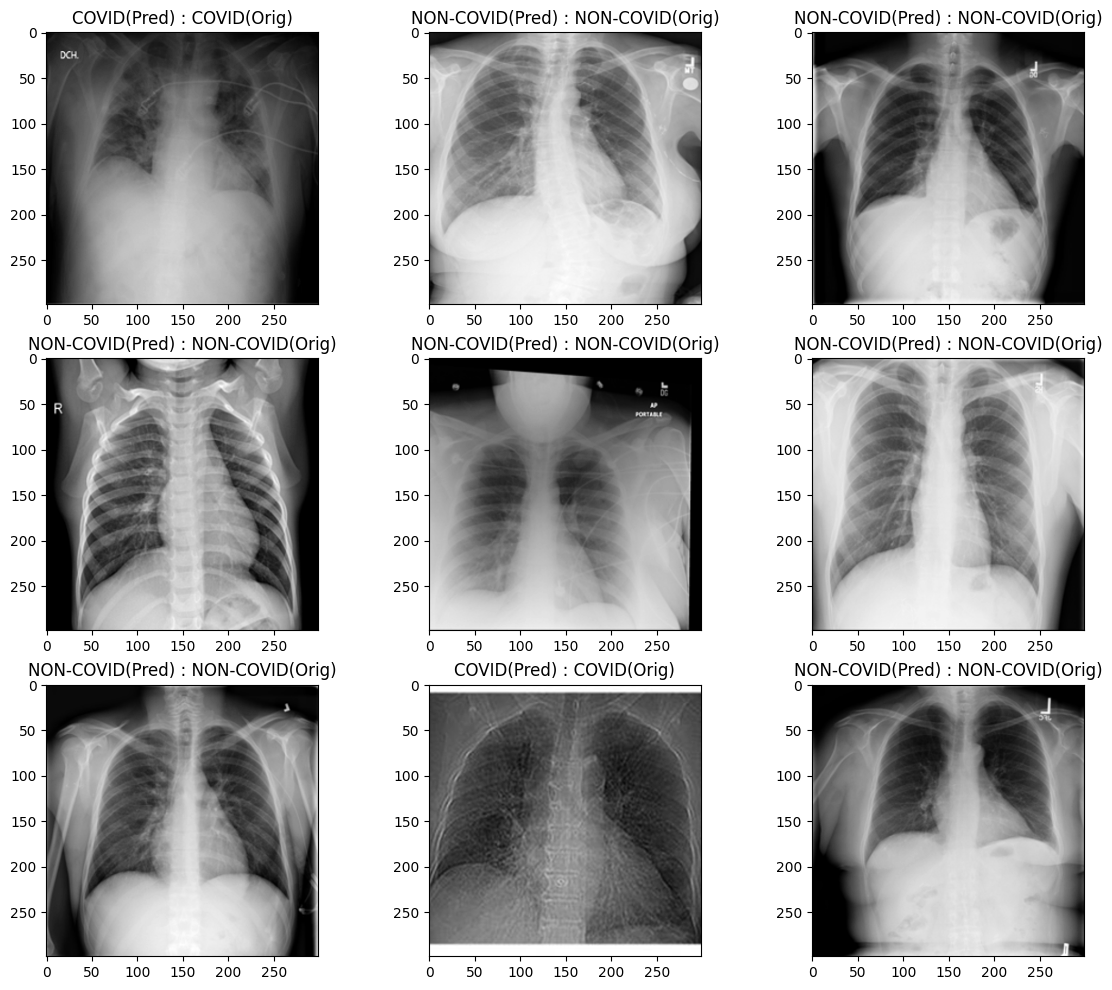

In [ ]:
train_object.pred_image_show(random_9_test)

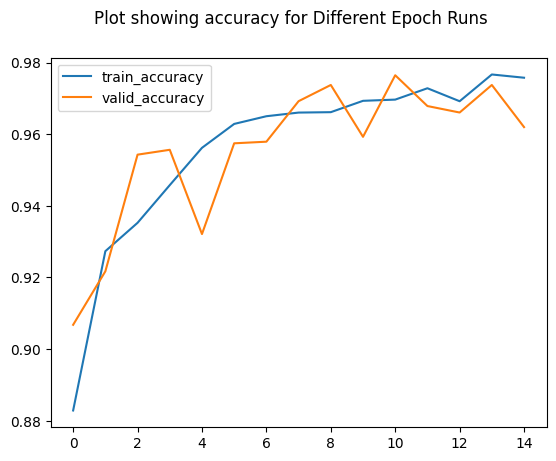

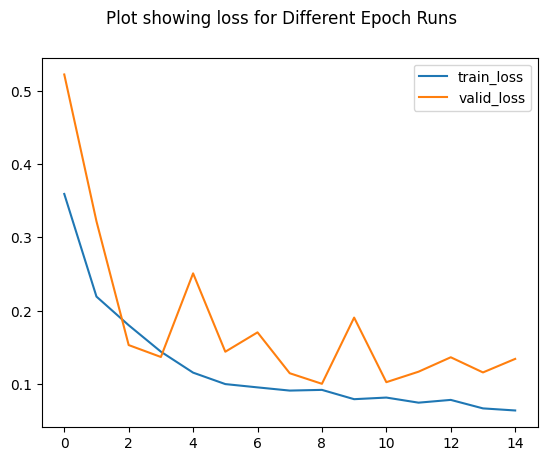

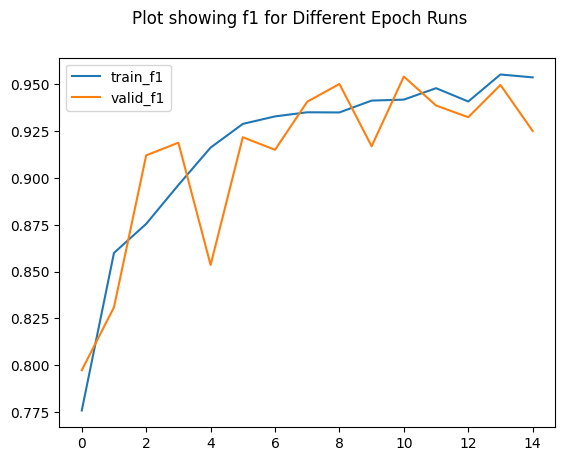

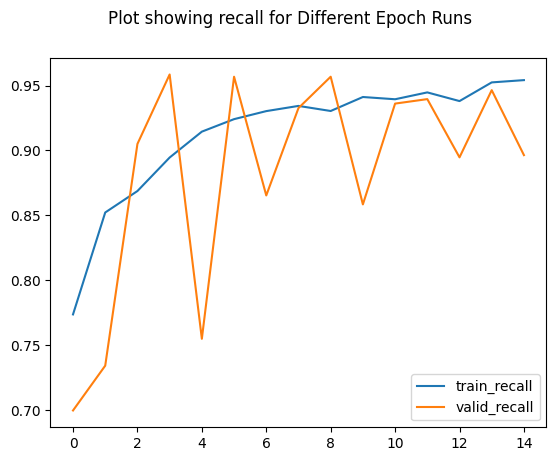

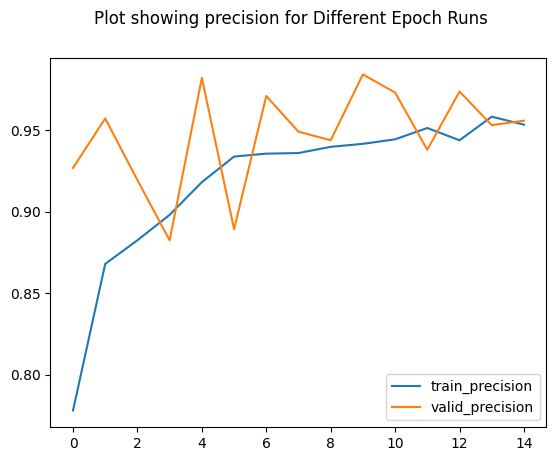

In [ ]:
train_object.plot_metrics()

In [ ]:
!cp ./*model_best_weights.zip ./gdrive/MyDrive/Manning_Projects/